# Word + Character Combinado

En este notebook combinamos representaciones de palabras y de caracteres en un único vector de características, que luego se pasa a la Regresión Logística. La idea es aprovechar simultáneamente la semántica de las palabras y los patrones ortográficos de los caracteres para clasificar la época del texto.

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## 2. Carga de los datos

In [2]:
df = pd.read_csv('train.csv')
df_eval = pd.read_csv('eval.csv')

In [3]:
df.head()

,text,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157
3,Caistro el M a y o r a i .] Del ape...,163
4,\nlos que panden macho ; y \notros en l...,166


In [4]:
df.shape

(31403, 2)

## 3. Exploración del conjunto de datos

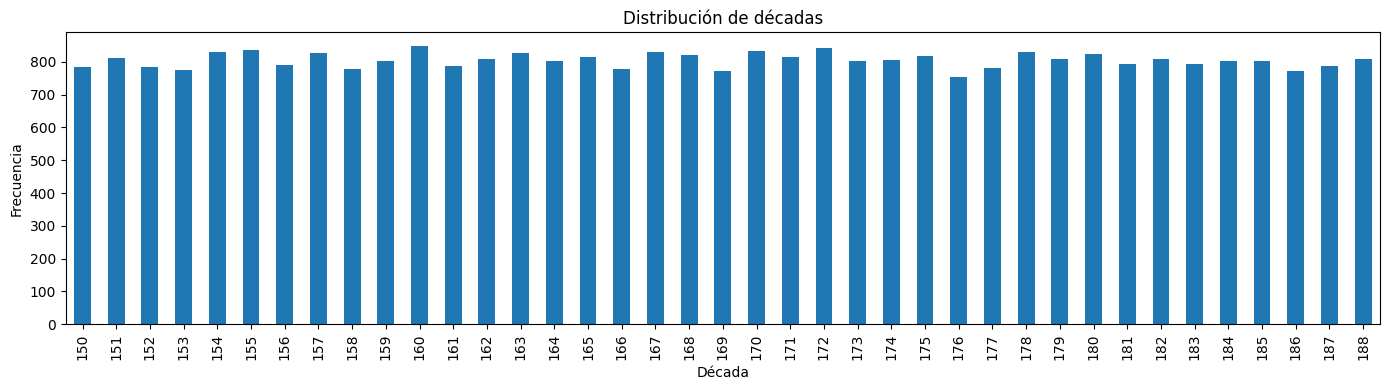

In [5]:
df['decade'].value_counts().sort_index().plot(
    kind='bar', figsize=(14, 4), title='Distribución de décadas'
)
plt.xlabel('Década')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [6]:
def reporte_calidad(df):
    reporte_de_cualidad = {
        'Total records': len(df),
        'duplicated record': df.duplicated().sum(),
        'missing values': df.isnull().sum().to_dict(),
        'data types': df.dtypes.astype(str).to_dict(),
    }
    return reporte_de_cualidad

print(reporte_calidad(df))

{'Total records': 31403, 'duplicated record': 34, 'missing values': {'text': 0, 'decade': 0}, 'data types': {'text': 'object', 'decade': 'int64'}}


## 4. Preprocesamiento del texto

Aplicamos una limpieza ligera: solo minúsculas y normalización de espacios. Conservamos más caracteres que en el enfoque de palabras puro para no perjudicar el componente de character n-grams.

In [7]:
def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

In [8]:
df = df.drop_duplicates().reset_index(drop=True)
df['texto_limpio'] = df['text'].apply(limpiar_texto)
df[['texto_limpio', 'decade']].head()

,texto_limpio,decade
0,honorarias ¡jubiladas. 57 dit.ad pontem de por...,164
1,"gone. sus amigos , sus clientes, todo cuanto l...",182
2,"prefosen quemanera,e per qualesfolpechas deuan...",157
3,caistro el m a y o r a i .] del apellido de ca...,163
4,los que panden macho ; y otros en la fu ña abu...,166


## 5. Partición de los datos

In [9]:
X = df['texto_limpio']
y = df['decade']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

Usamos `stratify=y` para mantener la distribución de clases.

In [10]:
X_train.shape, X_val.shape

((25095,), (6274,))

## 6. Construcción del pipeline

Usamos `FeatureUnion` para concatenar horizontalmente las matrices TF-IDF de palabras y de caracteres. El resultado es un único vector por documento que el clasificador recibe como entrada.

In [11]:
combinado = FeatureUnion([
    ('word', TfidfVectorizer(analyzer='word')),
    ('char', TfidfVectorizer(analyzer='char_wb')),
])

pipeline_combinado = Pipeline([
    ('features', combinado),
    ('clf', LogisticRegression(max_iter=1000, solver='saga')),
])

## 7. Entrenamiento con búsqueda de hiperparámetros

El espacio de búsqueda cubre el rango de n-grams y el tamaño de vocabulario de cada componente por separado, además del parámetro de regularización.

In [12]:
param_grid = {
    'features__word__ngram_range': [(1, 1), (1, 2)],
    'features__word__max_features': [20000, 30000],
    'features__char__ngram_range': [(3, 5)],
    'features__char__max_features': [20000, 30000],
    'clf__C': [0.1, 1, 10],
}

In [13]:
kfold = KFold(n_splits=5, shuffle=True, random_state=0)
grid_combinado = GridSearchCV(
    pipeline_combinado, param_grid, cv=kfold, scoring='accuracy', n_jobs=-1
)

In [ ]:
grid_combinado.fit(X_train, y_train)

In [ ]:
print('Mejores hiperparámetros:', grid_combinado.best_params_)
print('Mejor score CV (accuracy):', round(grid_combinado.best_score_, 4))

## 8. Evaluación del mejor modelo

In [ ]:
best_model = grid_combinado.best_estimator_

y_pred_train = best_model.predict(X_train)
y_pred_val   = best_model.predict(X_val)

#### Comparación de rendimientos sobre entrenamiento y validación

In [ ]:
print('Accuracy en entrenamiento:', round(accuracy_score(y_train, y_pred_train), 4))
print('Accuracy en validación:   ', round(accuracy_score(y_val,   y_pred_val),   4))
print('Mejor score CV (accuracy):', round(grid_combinado.best_score_,             4))

In [ ]:
print(classification_report(y_val, y_pred_val))

In [ ]:
fig, ax = plt.subplots(figsize=(16, 12))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val, ax=ax, colorbar=False)
plt.title('Matriz de confusión — validación')
plt.tight_layout()
plt.show()

## 9. Predicciones sobre eval.csv

In [ ]:
df_eval['texto_limpio'] = df_eval['text'].apply(limpiar_texto)

y_eval_pred = best_model.predict(df_eval['texto_limpio'])

submission = pd.DataFrame({'id': df_eval['id'], 'answer': y_eval_pred})
submission.to_csv('submission_word_char.csv', index=False)
submission.head()